# 1. HybridDynamics.jl ODE Solver Verification and Benchmarking

## Purpose of this notebook

This notebook tests the mathematical correctness and computational performance
of the ordinary differential equation (ODE) solvers implemented in
HybridDynamics.jl.

The primary goals are:

1. Verify that fixed-step numerical methods achieve their expected convergence
   orders.

2. Verify that adaptive-step methods correctly reduce numerical error when the
   requested error tolerance is decreased.

3. Compare adaptive solver efficiency using work-precision analysis.

The tests performed in this notebook focus first on systems with known exact
solutions. This allows the numerical error of each solver to be measured
directly.

Hybrid system event handling is intentionally avoided during the initial solver
verification tests. This allows us to isolate errors caused by the numerical
integrator itself from errors caused by event detection, reset maps, or hybrid
logic.

## Numerical Error and Convergence

Consider an initial value problem (IVP) of the form 

$$\frac{dx}{dt}=f(x,t),$$

with initial condition 

$$x(t_0) = x_0.$$

Here:

- $x(t)$ is the exact solution of the differential equation.
- $t$ is the independent time variable.
- $f(x,t)$ defines the dynamics of the system.
- $x_0$ is the initial state at time $t_0$.

A numerical solver produces an approximation:

$$
x_n \approx x(t_n).
$$

The error at the final simulation time $t_f$ is measured as:

$$E=\|x_n-x(t_f)\|.$$

where:

- $E$ is the numerical error.
- $x_n$ is the computed numerical solution at $t_f$.
- $x(t_f)$ is the exact analytical solution at $t_f$.
- $\|\cdot\|$ denotes the vector norm.

## Fixed-Step Methods

For fixed-step solvers, the timestep $h$ is manually selected.

The global error behaves approximately as:

$$
E(h)=Ch^p
$$ 

where

- $h$ is the timestep size.
- $p$ is the convergence order of the numerical method.
- $C$ is a constant determined by the problem and solver. 

Taking logarithms gives:
$$\log(E)=p\log(h)+\log(C).$$

Therefore, the slope of a log-log plot of error versus timestep gives the obersved convergence order.

## Adaptive-Step Methods

Adaptive solvers do not use a fixed timestep. Instead, they automatically adjust the timestep to satisfy a user-specified tolerance. 

The independent variable for convergence testing is therefore the requested error tolerance $(\tau)$, not the timestep.

For many adaptive methods:

$$
E(\tau)=C\tau^{\frac{p}{p+1}}
$$

where 

- $\tau$ is the requested local error tolerance.
- $p$ is the order of the underlying numerical method. 
- $E(\tau)$ is the resulting global error.

The expected slope in a log-log plot of error versus tolerance is therefore:

$$
\frac{p}{p+1}.
$$

In [1]:
###############################################################################
# Package Initialization
#
# This cell loads all external packages required for the verification tests.
#
# HybridDynamics:
#     The package containing the ODE and hybrid dynamical system solvers.
#
# LinearAlgebra:
#     Provides vector norms used to measure numerical error.
#
# Printf:
#     Provides formatted printing for benchmark tables.
#
# Plots:
#     Used to generate convergence and benchmarking figures.
###############################################################################

using Pkg

# Activate the HybridDynamics development environment.
# This allows the notebook to use the local package source.
Pkg.activate("..")

# Ensure that all dependencies are installed and available.
Pkg.resolve()
Pkg.instantiate()

# Compile dependencies before running benchmarks.
# This reduces timing variation caused by first-time compilation.
Pkg.precompile()


###############################################################################
# Import HybridDynamics
###############################################################################

import HybridDynamics as HD


###############################################################################
# Mathematical Utilities
###############################################################################

using LinearAlgebra


###############################################################################
# Output and Visualization Utilities
###############################################################################

using Printf
import Plots as plt

  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`
Precompiling packages...
   2203.7 ms  ✓ HybridDynamics
  1 dependency successfully precompiled in 3 seconds. 110 already precompiled.


In [2]:
###############################################################################
# Solver Definitions
#
# The following dictionaries organize the numerical methods tested in this
# notebook.
#
# Fixed-step solvers:
#     These methods require the user to provide the timestep h.
#     Their convergence is measured by repeatedly decreasing h.
#
# Adaptive-step solvers:
#     These methods automatically select h internally based on a requested
#     tolerance τ.
#     Their convergence is measured by decreasing τ.
###############################################################################


###############################################################################
# Fixed-Step Solvers
###############################################################################

fixed_solvers = Dict(
    "Forward Euler"         => HD.ForwardEuler(),
    "Modified Trapezoid"    => HD.ModifiedTrap(),
    "Modified Midpoint"     => HD.ModifiedMidpoint(),
    "Richardson Extrap."    => HD.RichardsonExtrapolation(),
    "RK4"                   => HD.RK4(),
    "Adams-Bashforth 2"     => HD.AdamsBashforth2(),
    "Adams-Bashforth 3"     => HD.AdamsBashforth3(),
    "BDF2"                  => HD.BDF2(),
    "BackwardEuler"         => HD.BackwardEuler(),
    "ImplicitTrap"          => HD.ImplicitTrap(),
    "RadauIIA"              => HD.RadauIIA()
)


###############################################################################
# Adaptive-Step Solvers
###############################################################################

adaptive_solvers = Dict(
    "Adaptive ABM2" => HD.AdaptiveABM2(),
    "Adaptive ABM3" => HD.AdaptiveABM3(),
    "RK23"          => HD.RK23(),
    "RK45"          => HD.RK45()
);

# Expected Solver Convergence Behavior

This section defines the theoretical convergence behavior expected from each
numerical method.

These values are not calculated from the simulations. They are reference values
based on the mathematical properties of each numerical integration method.

During the benchmark, the measured convergence rate will be compared against
these expected values.

## Fixed-Step Solvers

For fixed-step methods, the convergence order $p$ is defined through the relationship:

$$
E(h) = Ch^p
$$

where:

- $E(h)$ is the global numerical error.
- $h$ is the timestep size.
- $p$ is the theoretical order of the numerical method.
- $C$ is a problem-dependent constant.

A method with order $p$ should reduce the error by approximately a factor of:

$$
2^p
$$

when the timestep is reduced by a factor of two.


For example, RK4 has:

$$
p=4
$$

meaning that halving the timestep should reduce the error by approximately:

$$
2^4=16
$$

times.

In [3]:
###############################################################################
# Expected Fixed-Step Convergence Orders
#
# These values represent the theoretical global convergence order of each
# fixed-step numerical integration method.
#
# The benchmark will compare these expected values against the order measured
# from numerical experiments.
###############################################################################

expected_fixed = Dict(

    # First-order methods:
    # Error decreases proportionally to timestep size.
    "Forward Euler"  => 1.0,


    # Second-order methods:
    # Error decreases proportionally to timestep squared.
    "Modified Trapezoid" => 2.0,
    "Modified Midpoint"  => 2.0,
    "Adams-Bashforth 2"  => 2.0,
    "BDF2"               => 2.0,


    # Third-order methods:
    "Richardson Extrap." => 3.0,
    "Adams-Bashforth 3"  => 3.0,


    # Fourth-order Runge-Kutta:
    "RK4" => 4.0,

    # Implicit Methods:
    "BackwardEuler" => 1.0,
    "ImplicitTrap" => 2.0,
    "RadauIIA" => 3.0
);

## Adaptive-Step Solvers

Adaptive methods require a different convergence analysis because the timestep is not chosen directly by the user. 

Instead, the user provides a tolerance:

$$
\tau.
$$

The solver automatically chooses the timestep $h$ necessary to approximately satify this tolerance. FOr many adaptive error controllers, the relationship between global error and tolerance is 

$$
E(\tau) = C\tau ^{\frac{p}{p+1}}
$$

where

- $E(\tau)$ is the observed global error.
- $\tau$ is the requested solver tolerance.
- $p$ is the order of the underlying integration method.
- $C$ is a problem-dependent constant.

Therefore, the expected slope of a log-log plot of error versus tolerance is:

$$
m=\frac{p}{p+1}.
$$

This slope is not the same as the fixed-step order. For example, RK4 has $p=4$ so the expected tolerance slope is $\frac{4}{4+1}=0.8$ rather than $4$.

In [4]:
###############################################################################
# Expected Adaptive Solver Tolerance Scaling
#
# These values represent the expected slope of:
#
#       log(error) versus log(tolerance)
#
# The values are computed from:
#
#       slope = p/(p+1)
#
# where p is the order of the underlying integration method.
###############################################################################

expected_adaptive = Dict(

    # Adaptive Adams-Bashforth-Moulton 2:
    # Underlying method order p = 2
    "Adaptive ABM2" => 2.0 / 3.0,


    # Adaptive Adams-Bashforth-Moulton 3:
    # Underlying method order p = 3
    "Adaptive ABM3" => 3.0 / 4.0,


    # Embedded Runge-Kutta 2(3) method:
    # Lower order used in error estimation is p = 2
    "RK23" => 2.0 / 3.0,


    # Embedded Runge-Kutta 4(5) method:
    # Lower order used in error estimation is p = 4
    "RK45" => 4.0 / 5.0
);

# Test Dynamical Systems

To accurately measure solver convergence, each test system must have a known analytical solution. The numerical solution produced by HybridDynamics.jl can then be compared against the exact solution:

$$
E = \|x_{\text{numerical}}(t_f)-x_{\text{exact}(t_f)}\|
$$

where:

- $x_{\text{numerical}}(t_f)$ is the final state computed by the solver.
- $x_{\text{exact}}(t_f)$ is the known analytical solution.
- $t_f$ is the final simulation time.

The systems below represent several categories supported by HybridDynamics.jl. Note, we offer more but they do not make sense for this particular benchmark.

1. General Systems.
2. Filippov Systems.
3. Mechanical Systems.
4. Nonholonomic Systems.
5. Linear/Affine Systems.

The initial solver verification avoids events by placing the guard surfaces far away from the trajectory. This ensures that measured error comes from the ODE integration method rather than event localization. 

In [5]:
###############################################################################
# General Nonlinear System
#
# Differential equation:
#
#     dx/dt = [-x₁², -x₂²]
#
# Exact solution:
#
#     x(t) = [1/(1+t), 1/(1+t)]
#
# The guard condition is placed at x₁ = 100 so that no event occurs during the
# simulation interval.
###############################################################################

sys_general() = HD.GeneralSystem(
    (u,t) -> [-u[1]^2, -u[2]^2],
    u -> u[1] - 100.0,
    u -> [u[1], u[2]];
    direction=1
)

exact_general(t) = [
    1.0/(1.0+t),
    1.0/(1.0+t)
];

In [6]:
###############################################################################
# Filippov System
#
# Vector field:
#
#     dx/dt = [-x₁, -x₂]
#
# Exact solution:
#
#     x(t) = [exp(-t), exp(-t)]
#
# The guard surface is intentionally outside the trajectory to avoid triggering
# discontinuous dynamics during convergence testing.
###############################################################################

sys_filippov() = HD.FilippovSystem(
    x -> [-x[1], -x[2]],
    x -> [0.0, 0.0],
    x -> x[1] + 100.0,
    x -> [1.0, 0.0]
)

exact_filippov(t) = [
    exp(-t),
    exp(-t)
];

In [7]:
###############################################################################
# Mechanical System
#
# This system represents a simple harmonic oscillator.
#
# The exact solution is:
#
#     q(t) = [cos(t), sin(t)]
#
#     dq/dt = [-sin(t), cos(t)]
#
# Therefore the full state is:
#
#     x(t) =
#     [cos(t),
#      sin(t),
#     -sin(t),
#      cos(t)]
###############################################################################

sys_mechanical() = HD.MechanicalSystem(
    q -> [1.0 0.0; 0.0 1.0],
    q -> 0.5*(q[1]^2 + q[2]^2);
    guard=q -> q[1]+100.0,
    normal=q -> [1.0,0.0],
    e=1.0
)

exact_mechanical(t) = [
    cos(t),
    sin(t),
    -sin(t),
    cos(t)
];

In [8]:
###############################################################################
# Nonholonomic Mechanical System
#
# This system tests constrained mechanical dynamics.
#
# The state contains:
#
#     x = [q₁, q₂, q₃, v₁, v₂, v₃]
#
# where:
#
#     qᵢ = generalized coordinates
#     vᵢ = generalized velocities
#
# The exact solution used for verification is:
#
#     x(t) =
#
#     [ cos(t),
#       0,
#       0,
#      -sin(t),
#       0,
#       0 ]
#
# As with the other systems, the guard surface is placed far away so that the
# numerical solver can be tested without hybrid events occurring.
###############################################################################

sys_nonholonomic() = HD.NonholonomicSystem(
    q -> [
        1.0 0.0 0.0;
        0.0 1.0 0.0;
        0.0 0.0 1.0
    ] .* one(eltype(q)),

    q -> 0.5*(q[1]^2 + q[2]^2);

    A = q -> [
        -sin(q[3]) cos(q[3]) 0.0
    ],

    guard = q -> q[1]+100.0,
    normal = q -> [1.0,0.0,0.0],
    e=1.0
)


exact_nonholonomic(t) = [
    cos(t),
    0.0,
    0.0,
    -sin(t),
    0.0,
    0.0
];

In [9]:
###############################################################################
# Linear System
#
# This system represents a diagonal linear ODE:
#
#       dx/dt = Ax + b
#
# with:
#
#       A = [-1  0
#             0 -2]
#
# The analytical solution is:
#
#       x(t) =
#
#       [ exp(-t),
#         exp(-2t) ]
#
# This provides a simple smooth benchmark where solver behavior can be compared
# against an exact exponential solution.
###############################################################################

sys_linear() = HD.LinearSystem(
    [
        -1.0 0.0;
         0.0 -2.0
    ],
    [1.0,0.0],
    [
        1.0 0.0;
        0.0 1.0
    ]
)


exact_linear(t) = [
    exp(-t),
    exp(-2.0*t)
]

exact_linear (generic function with 1 method)

In [10]:
###############################################################################
# Affine System
#
# This system tests equations of the form:
#
#       dx/dt = Ax + b
#
# where:
#
#       A is the linear dynamics matrix
#       b is a constant forcing term
#
# The exact solution is:
#
#       x(t) =
#
#       [2 - exp(-t),
#        3 - 2exp(-t)]
#
# This provides a benchmark for systems containing both linear dynamics and
# constant forcing.
###############################################################################

sys_affine() = HD.AffineSystem(
    [
        -1.0 0.0;
         0.0 -1.0
    ],

    [2.0,3.0],

    [1.0,0.0],

    100.0,

    [
        1.0 0.0;
        0.0 1.0
    ],

    [0.0,0.0]
)


exact_affine(t) = [
    2.0-exp(-t),
    3.0-2.0*exp(-t)
]

exact_affine (generic function with 1 method)

## Unified Test System Collection

Each entry in the system dictionary contains:

- `sys`: A function that creates the HybridDynamics system object.
- `x0`: The initial condition $x(t_0)$.
- `tspan`: The simulation interval, $(t_0, t_f)$. Where $t_0$ and $t_f$ are the initial and final times respectively. 
- `exact`: The analytical solution used to calculate the numerical error.

The dictionary format allows the same benchmark routines to test every system without modification. 

In [11]:
###############################################################################
# Collection of Benchmark Systems
#
# Each system stores:
#
# sys:
#     Function that constructs the HybridDynamics system.
#
# x0:
#     Initial state vector.
#
# tspan:
#     Simulation interval (initial time, final time).
#
# exact:
#     Analytical solution function.
###############################################################################

systems = Dict(

    "General" => (
        sys=sys_general,
        x0=[1.0,1.0],
        tspan=(0.0,0.5),
        exact=exact_general
    ),


    "Filippov" => (
        sys=sys_filippov,
        x0=[1.0,1.0],
        tspan=(0.0,2.0),
        exact=exact_filippov
    ),


    "Mechanical" => (
        sys=sys_mechanical,
        x0=[1.0,0.0,0.0,1.0],
        tspan=(0.0,1.0),
        exact=exact_mechanical
    ),


    "Nonholonomic" => (
        sys=sys_nonholonomic,
        x0=[1.0,0.0,0.0,0.0,0.0,0.0],
        tspan=(0.0,1.0),
        exact=exact_nonholonomic
    ),


    "Linear" => (
        sys=sys_linear,
        x0=[1.0,1.0],
        tspan=(0.0,2.0),
        exact=exact_linear
    ),


    "Affine" => (
        sys=sys_affine,
        x0=[1.0,1.0],
        tspan=(0.0,2.0),
        exact=exact_affine
    )
);

# Utility Functions

The benchmark routines require several repeated calculations. These helper functions provide:

1. Error measurement.
2. Log-log slope estimation.
3. Numerical Formatting.

The same utilities will be used for both fixed-step and adaptive-step testing. This avoids having separate implementations of the same mathematical calculations so just keep that in mind. 

In [12]:
###############################################################################
# Compute Terminal Error
#
# Calculates the difference between the numerical solution and the exact
# analytical solution at the final simulation time.
#
# Input:
#
# sol:
#     HybridDynamics solution object.
#
# exact:
#     Analytical solution function.
#
# tf:
#     Final simulation time.
#
# Output:
#
# Scalar error value:
#
#       E = ||x_numeric(tf)-x_exact(tf)||
###############################################################################

function terminal_error(sol, exact, tf)

    x_exact = exact(tf)

    x_numeric = sol.x[end]

    return norm(x_numeric - x_exact)

end

terminal_error (generic function with 1 method)

In [13]:
###############################################################################
# Estimate Log-Log Convergence Slope
#
# Given data satisfying approximately:
#
#       y = Cx^p
#
# taking logarithms gives:
#
#       log(y)=p log(x)+log(C)
#
# Therefore the slope of a linear fit in log-space estimates p.
#
# Inputs:
#
# x:
#     Independent variable.
#
# y:
#     Error values.
#
# Output:
#
# Estimated convergence slope.
###############################################################################

function estimate_slope(x,y)

    logx = log10.(x)
    logy = log10.(y)

    A = hcat(logx, ones(length(logx)))

    coefficients = A \ logy

    return coefficients[1]

end

estimate_slope (generic function with 1 method)

# 2. Fixed-Step Solver Verification

Fixed-step solvers use a user-selected timestep size $h$. The numerical solution is generated at discrete times: 
$$
t_n = t_0 + h
$$

where:

- $t_n$ is the $n$-th numerical time point.
- $t_0$ is the initial simulation time. 
- $n$ is the timestep index.
- $h$ is the fixed timestep size. 

The goal of this section is to determine whether each solver achieves its expected convergence order. 

## Convergence Order

A numerical method has convergence order $p$ if the global error behaves as $E(h) = Ch^p$. As seen in previous sections, if we take logarithms 

$$
\log(E)=p\log(h)+\log(C)
$$

This means that a log-log plot of error vs. times the slope of this line will give the observed numerical order of an integration method:

$$
p_{\text{observed}}=\frac{\Delta\log(E)}{\Delta\log(h)}.
$$

For each fixed-step solver:

1. Select a sequence of decreasing timesteps.
2. Solve the system for each timestep.
3. Compute the terminal error. 
4. Fit a line in logarithmic space.
5. Compare the measured order against the theoretical order.

In [14]:
###############################################################################
# Fixed-Step Refinement Values
#
# Each solver is tested using a sequence of decreasing timestep sizes.
#
# Smaller values of h should produce smaller numerical errors for a convergent
# method.
#
# The sequence used is:
#
#     h = 2^(-2), 2^(-3), ..., 2^(-10)
#
# which corresponds to repeatedly halving the timestep.
###############################################################################

dts_fixed = 2.0 .^ (-(2:10));

## Fixed-Step Convergence Test Function

The following function performs the complete convergence experiment for a single
dynamical system.

For each solver:

- A problem is created using the selected system.
- The solver is run using each timestep value $h$.
- The terminal error is calculated.
- The observed convergence order is estimated.

The returned data is stored so that plots and tables can be generated afterward.

In [15]:
###############################################################################
# Fixed-Step Solver Convergence Test
#
# Runs all fixed-step solvers on one dynamical system.
#
# Returns:
#
# results:
#     Dictionary containing:
#
#       errors:
#           Numerical errors corresponding to each timestep.
#
#       order:
#           Measured convergence order.
#
#       dts:
#           Timestep values used.
###############################################################################

function fixed_step_convergence(spec, solvers, dts)

    results = Dict()

    prob = HD.prob(spec.sys(), spec.x0, spec.tspan)

    tf = spec.tspan[end]

    for (solver_name, solver) in solvers

        errors = zeros(length(dts))

        for (i,h) in enumerate(dts)

            sol = HD.solve(prob, solver; dt_initial=h)

            errors[i] = terminal_error(sol, spec.exact, tf)

        end

        order = estimate_slope(dts, errors)

        results[solver_name] = (errors=errors, order=order, dts=dts)

    end
    return results
end;

In [16]:
###############################################################################
# Run Fixed-Step Verification
#
# The benchmark is performed for every test system and every fixed-step solver.
###############################################################################

fixed_results = Dict()


for (system_name, spec) in systems
    println("\nRunning fixed-step tests for: ", system_name)
    fixed_results[system_name] = fixed_step_convergence(spec, fixed_solvers, dts_fixed)
end


Running fixed-step tests for: Affine

Running fixed-step tests for: General

Running fixed-step tests for: Mechanical

Running fixed-step tests for: Nonholonomic

Running fixed-step tests for: Filippov

Running fixed-step tests for: Linear


In [17]:
###############################################################################
# Fixed-Step Order Summary
#
# Compares measured convergence order against theoretical expectations.
###############################################################################

function print_fixed_summary(results, expected)

    println(
        rpad("Solver", 25),
        rpad("Expected", 12),
        rpad("Measured", 12),
        "Percent"
    )

    println("-"^65)

    for (solver, data) in results

        expected_order = expected[solver]
        measured_order = data.order

        ratio = measured_order / expected_order
        percent_diff = 100 * abs(measured_order - expected_order) / abs(expected_order)

        println(
            rpad(solver, 25),
            rpad(round(expected_order, digits=4), 12),
            rpad(round(measured_order, digits=4), 12),
            "$(round(percent_diff, digits=2))%"
        )
    end
end

print_fixed_summary (generic function with 1 method)

The above function can be used for any of the system types we may want to test. For example we test Linear systems below

In [42]:
print_fixed_summary(
    fixed_results["Nonholonomic"], # Change this here to test other systems!
    expected_fixed
)

Solver                   Expected    Measured    Percent
-----------------------------------------------------------------
Adams-Bashforth 3        3.0         2.9099      3.0%
ImplicitTrap             2.0         1.9989      0.05%
BackwardEuler            1.0         0.9892      1.08%
Modified Midpoint        2.0         1.9999      0.0%
Richardson Extrap.       3.0         3.0001      0.0%
RadauIIA                 3.0         2.9994      0.02%
Adams-Bashforth 2        2.0         1.9639      1.8%
RK4                      4.0         4.0046      0.12%
BDF2                     2.0         1.9312      3.44%
Forward Euler            1.0         1.0069      0.69%
Modified Trapezoid       2.0         1.9999      0.0%


## Fixed-Step Convergence Plots

Each plot displays error vs. timestep size $h$ on logarithmic axes. 

In [19]:
###############################################################################
# Plot Fixed-Step Convergence
###############################################################################

function plot_fixed_convergence(
    system_name,
    results
)

    plt.plot(
        xlabel="Timestep h",
        ylabel="Terminal Error",
        title="Fixed-Step Convergence: $system_name",
        xscale=:log10,
        yscale=:log10,
        legend=:outerright,
        grid=true
    )

    # Sort results by measured order so the legend labels appear in order of convergence order
    sorted_results = sort(collect(results), by = x -> x[2].order)

    for (solver, data) in sorted_results

        plt.plot!(
            data.dts,
            data.errors,
            marker=:circle,
            label="$(solver) p≈$(round(data.order, digits=2))"
        )

    end

    display(plt.current())

end

plot_fixed_convergence (generic function with 1 method)

As an example similarly to our last one, see below for Linear.

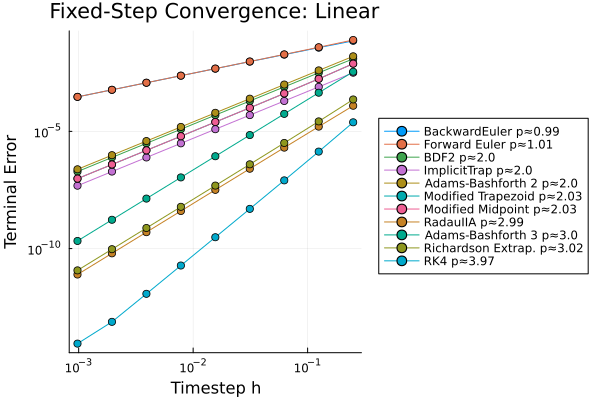

In [47]:
plot_fixed_convergence(
    "Linear",
    fixed_results["Affine"]
)

# 3.Adaptive Solver Verification

Adaptive solvers differ from the fixed-step methods because the timestep is not chosen directly by the user. Instead the user specifies an error tolerance $\tau$ and the solver automatically selects timesteps that attempt to satisfy this requirement. 

## Adaptive Step Selection 

During integration, adaptive methods estimate the local truncation error (LTE) for each proposed timestep. The solver compares this estimate against the requested tolerance, LTE $\leq \tau$. If the estimated error is too large, the timestep is rejected and reduced. If the estimated error is sufficiently small, the timestep is accepted and the solver may increase the timestep. 

## Expected Error Scaling 

For many adaptive methods, the global error behaves approximately as $E(\tau)=C\tau^{\alpha}$ where:

- $E(\tau)$ is the final numerical error.
- $C$ is a problem dependent constant.
- $\alpha$ is the observed tolerance scaling exponent. 

For standard adaptive controllers, $\alpha = \frac{p}{p+1}$ with $p$ as the order of the numerical method used. 

Therefore, in our case, the expected slopes are:

| Solver | Order $p$ | Expected Slope |
|---|---:|---:|
| Adaptive ABM2 | 2 | 0.667 |
| Adaptive ABM3 | 3 | 0.750 |
| RK23 | 2 | 0.667 |
| RK45 | 4 | 0.800 |

These values are used as a reference. Small deviations are expected because adaptive controllers contain safety factors, step rejection logic, and min/max timestep restrictions. 


## Adaptive Solver Tolerance Selection

The tolerance sequence controls how strictly the adaptive solver is required to limit local error. A smaller tolerance requires a more accurate solution and usually results in more computational work. The tests below use logarithmically spaced tolerances $\tau = 10^{-k}$ where $k$ is increased to request progressively higher accuracy. Each solver is tested over a ran ge appropriate for its expected numerical behavior. 

In [21]:
###############################################################################
# Adaptive Solver Tolerances
#
# Each adaptive solver is tested with progressively smaller tolerances.
#
# Smaller tolerance values request greater accuracy from the solver.
#
# The resulting error behavior is used to estimate:
#
#       log(error) versus log(tolerance)
#
# scaling.
###############################################################################

tols_adaptive = Dict(

    # RK45 generally handles tighter tolerances well because of its higher order.
    "RK45" =>
        10.0 .^ range(-4,-9,length=6),


    # Lower-order adaptive methods are tested over a slightly less aggressive
    # tolerance range.
    "RK23" =>
        10.0 .^ range(-3,-8,length=6),


    "Adaptive ABM2" =>
        10.0 .^ range(-3,-8,length=6),


    "Adaptive ABM3" =>
        10.0 .^ range(-3,-8,length=6)
);

## Adaptive Convergence Experiment

For each adaptive solver:

1. Select a tolerance value $\tau$.
2. Solve the differential equation.
3. Compute the terminal error.

$$
E = \| x_{\text{numerical}}(t_f) - x_{\text{exact}}(t_f)\|
$$

4. Repeat for decreasing tolerances.
5. Estimate the tolerance scaling exponent using a log-log fit. 

The resulting slope estimates $E(\tau)\approx C\tau^\alpha$.

In [22]:
###############################################################################
# Adaptive Solver Convergence Test
#
# Runs one adaptive solver on one test system.
#
# Inputs:
#
# spec:
#     Test system description.
#
# solver_name:
#     Name of adaptive solver.
#
# solver:
#     HybridDynamics solver object.
#
# tolerances:
#     Array of requested solver tolerances.
#
# Returns:
#
# errors:
#     Numerical error for each tolerance.
#
# slope:
#     Observed log(error)-log(tolerance) slope.
###############################################################################

function adaptive_convergence(spec, solver_name, solver, tolerances)

    prob = HD.prob(spec.sys(), spec.x0, spec.tspan)

    tf = spec.tspan[end]

    errors = zeros(length(tolerances))

    for (i,tol) in enumerate(tolerances)

        sol = HD.solve(prob, solver; tol=tol)

        errors[i] = terminal_error(sol, spec.exact, tf)
    end

    slope = estimate_slope(tolerances, errors)

    return (errors=errors, tolerances=tolerances, slope=slope)
end

adaptive_convergence (generic function with 1 method)

In [23]:
###############################################################################
# Run Adaptive Solver Verification
#
# Results are stored in a nested dictionary:
#
# adaptive_results[system][solver]
#
# Example:
#
# adaptive_results["Linear"]["RK45"]
#
# contains the RK45 tolerance convergence data for the Linear system.
###############################################################################

adaptive_results = Dict()

for (system_name,spec) in systems

    println("\nRunning adaptive tests for: ", system_name)

    adaptive_results[system_name] = Dict()

    for (solver_name,solver) in adaptive_solvers

        adaptive_results[system_name][solver_name] =
            adaptive_convergence(spec, solver_name, solver, tols_adaptive[solver_name])
    end
end


Running adaptive tests for: Affine

Running adaptive tests for: General

Running adaptive tests for: Mechanical

Running adaptive tests for: Nonholonomic

Running adaptive tests for: Filippov

Running adaptive tests for: Linear


We now have `adaptive_results["system"]["solver"]` which will contain the tolerances tested, errors produced, and measured tolerance slope. The next section will create the adaptive error vs. tolerance plots . 

# Adaptive Error vs. Tolerance Plots

The primary convergence plot for adaptive solvers is different from the fixed-step case as we have mentioned before. A successful adaptive solver should show:

1. Error decreasing as tolerance decreases.
2. Approximately linear behavior on logarithmic axes.
3. A slope close to the theoretical tolerance scaling exponent. (Recall $\alpha = \frac{p}{p+1})$

In [24]:
###############################################################################
# Plot Fixed-Step Convergence
###############################################################################

function plot_adaptive_convergence(system_name, results)

    plt.plot(
        xlabel="Tolerance τ",
        ylabel="Terminal Error",
        title="Adaptive Solver Convergence: $system_name",
        xscale=:log10,
        yscale=:log10,
        legend=:outerright,
        grid=true
    )

    # Sort results by measured slope so the legend labels appear in order of convergence slope
    sorted_results = sort(collect(results), by = x -> x[2].slope)

    for (solver_name, data) in sorted_results

        plt.plot!(
            data.tolerances,
            data.errors,
            marker=:circle,
            label="$(solver_name) α≈$(round(data.slope, digits=3))"
        )

    end

    display(plt.current())

end

plot_adaptive_convergence (generic function with 1 method)

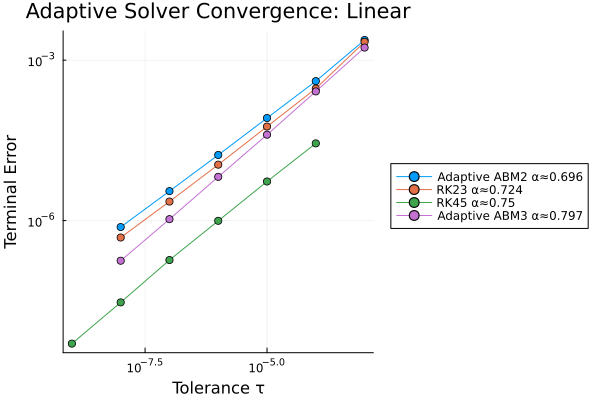

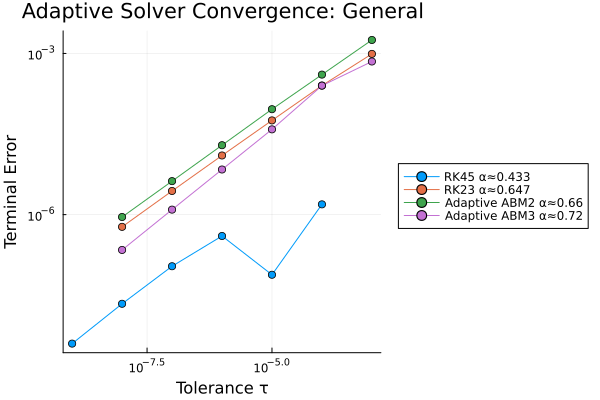

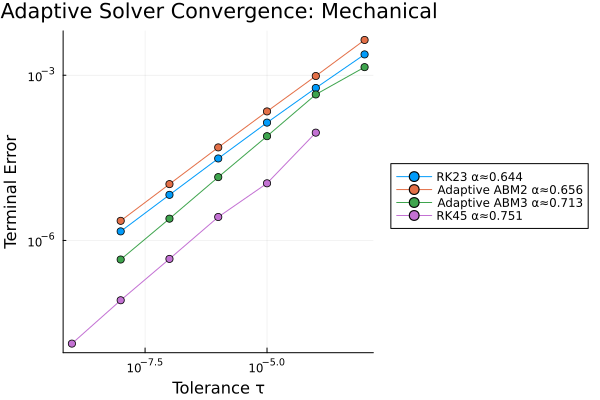

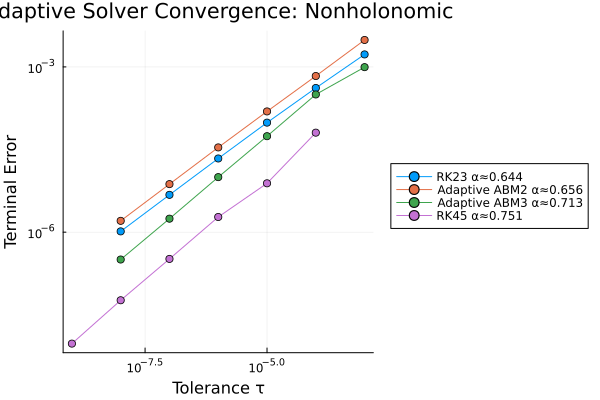

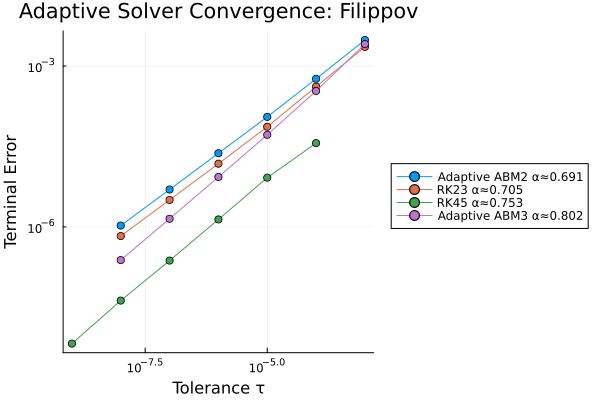

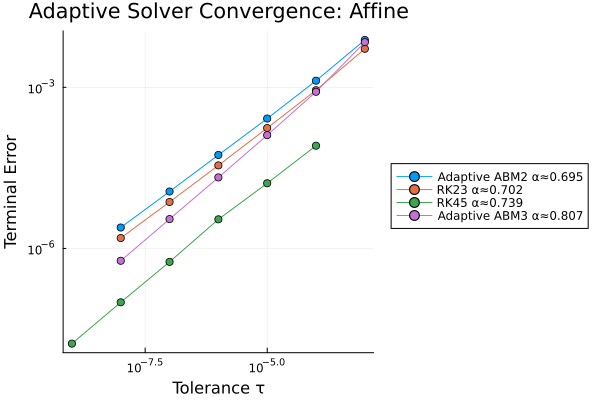

In [25]:
for system_name in keys(adaptive_results)
    plot_adaptive_convergence(
        system_name,
        adaptive_results[system_name]
    )
end

## Adaptive Tolerance Scaling Summary

The measured slope is obtained from the least-squares fit: 

$$
\log(E) = \alpha \log(\tau)+C.
$$

Measured value is compared against the theoretical expectation. Small differences are expected as adaptive controllers introduce practical effects outlined above.

In [26]:
###############################################################################
# Adaptive Solver Summary Table
#
# Prints measured tolerance scaling compared with theoretical expectation.
###############################################################################

function print_adaptive_summary(results, expected)

    println(
        rpad("Solver", 25),
        rpad("Expected", 12),
        rpad("Measured", 12),
        "Percent"
    )

    println("-"^65)

    for (solver_name, data) in results

        expected_value = expected[solver_name]
        measured_value = data.slope

        ratio = measured_value / expected_value
        percent_diff = 100 * abs(measured_value - expected_value) / abs(expected_value)

        println(
            rpad(solver_name, 25),
            rpad(round(expected_value, digits=4), 12),
            rpad(round(measured_value, digits=4), 12),
            "$(round(percent_diff, digits=2))%"
        )
    end
end

print_adaptive_summary (generic function with 1 method)

Using this new function is seen below. 

In [27]:
print_adaptive_summary(
    adaptive_results["Filippov"],
    expected_adaptive
)
# Change this to see the other system types.

Solver                   Expected    Measured    Percent
-----------------------------------------------------------------
RK23                     0.6667      0.7049      5.73%
RK45                     0.8         0.7526      5.92%
Adaptive ABM2            0.6667      0.6907      3.6%
Adaptive ABM3            0.75        0.8023      6.97%


## Monotonic Convergence Test

For a correctly functioning adaptive solver, decreasing the requested tolerance should generally decrease the final numerical error. Given tolerances:

$$
\tau_1 > \tau_2 > \tau_3 > \dots
$$

we expect:

$$
E(\tau_1)>E(\tau_2)>E(\tau_3)>\dots
$$

This condition does not need to hold perfectly at extremely small tolerances because floating point roundoff may eventually dominate. However, large increases in error when tightening the tolerance indicate possible problems with the adaptive controller. 

In [28]:
###############################################################################
# Adaptive Monotonicity Check
#
# Checks whether error decreases as tolerance decreases.
#
# Returns:
#
# true:
#     Error decreases monotonically.
#
# false:
#     At least one tighter tolerance produced larger error.
###############################################################################

function check_monotonic_convergence(errors)
    for i in 2:length(errors)
        if errors[i] > errors[i-1]
            return false
        end
    end
    return true
end

check_monotonic_convergence (generic function with 1 method)

In [29]:
###############################################################################
# Print Adaptive Convergence Behavior
###############################################################################

function print_monotonic_summary(results)

    println(
        rpad("Solver",25),
        "Monotonic?"
    )

    println("-"^40)

    for (solver_name,data) in results

        passed = check_monotonic_convergence(data.errors)

        println(
            rpad(solver_name,25),
            passed
        )
    end
end

print_monotonic_summary (generic function with 1 method)

In [30]:
print_monotonic_summary(
    adaptive_results["Mechanical"]
)
#Change this to see the other system types

Solver                   Monotonic?
----------------------------------------
RK23                     true
RK45                     true
Adaptive ABM2            true
Adaptive ABM3            true


# 4. Adaptive Work-Precision Benchmarking

Convergence analysis measures how accurately a solver approximates the solution. However, accuracy alone does not determine whether a solver is efficient. Two solvers may achioeve the same final error while requiring very different amounts of computational effort. 

Work-Precision analysis evaluates the relationship between:

1. Computational work.
2. Numerical Precision. 

The ideal solver achieves low error with minimal computational cost. 

## Work-Precision Relationship

A work-precision diagram plots error against computational work (usually on logarithmic axes). A more efficient solver appears further towards the lower-left corner:

- left = less computational work,
- down = smaller numerical error.

For adaptive ODE solvers, computational work is commonly measured using: 

- number of accepted steps,
- number of rejected steps,
- number of function evaluations,
- CPU time.

For this notebook we will primarily use number of accepted timesteps because it is solver-independent and available directly from our solution objects. 

## Current Work Metric

Because the current solution structure does not expose the internal adaptive controller statistics, computational work is estimated using $W=N$ where $W$ is the measured work and $N$ is the number of accepted timestamps. The length of accepted steps is calculated as: 

$$
N = length(t) - 1
$$

where $t$ is the vector of saved solution times. This provides a solver-independent estimate of integration effort. Future versions of HybridDynamics.jl could improve this but we will get there one day!

In [31]:
###############################################################################
# Estimate Computational Work
#
# Current implementation:
#
#       work = number of accepted timesteps
#
# This uses only information already stored in the solution object. 
# We hope to update this soon!
###############################################################################

function estimate_work(sol)
    return length(sol.t)-1
end

estimate_work (generic function with 1 method)

In [32]:
###############################################################################
# Adaptive Work-Precision Data Collection
#
# Runs adaptive solvers and stores:
#
# tolerance
# numerical error
# computational work
###############################################################################

function adaptive_work_precision(spec, solver, tolerances)

    prob = HD.prob(spec.sys(), spec.x0, spec.tspan)

    tf = spec.tspan[end]

    errors = zeros(length(tolerances))

    work = zeros(length(tolerances))

    for (i,tol) in enumerate(tolerances)

        sol = HD.solve(prob, solver; tol=tol)

        errors[i] =
            terminal_error(sol, spec.exact, tf)
        work[i] =
            estimate_work(sol)
    end

    return (tolerances=tolerances, errors=errors, work=work)
end

adaptive_work_precision (generic function with 1 method)

In [33]:
###############################################################################
# Run Work-Precision Benchmark
###############################################################################

work_results = Dict()

for (system_name,spec) in systems

    println(
        "\nRunning work benchmark: ",
        system_name
    )

    work_results[system_name] = Dict()

    for (solver_name,solver) in adaptive_solvers

        work_results[system_name][solver_name] =
            adaptive_work_precision(spec, solver, tols_adaptive[solver_name])
    end
end


Running work benchmark: Affine

Running work benchmark: General

Running work benchmark: Mechanical

Running work benchmark: Nonholonomic

Running work benchmark: Filippov

Running work benchmark: Linear


## Work-Precision Curves

The work-precision plot shows $E(W)$. The best solver minimizes effort while requiring fewer steps. Therefore, curves closer to the lower-left corner indicate better efficiency. 

In [34]:
###############################################################################
# Work-Precision Plot
###############################################################################

function plot_work_precision(system_name, results)

    plt.plot(
        xlabel="Accepted Steps",
        ylabel="Terminal Error",
        title="Work-Precision: $system_name",
        xscale=:log10,
        yscale=:log10,
        legend=:outerright,
        grid=true
    )

    for (solver_name,data) in results

        plt.plot!(
            data.work,
            data.errors,
            marker=:circle,
            label=solver_name
        )

    end

    display(plt.current())

end

plot_work_precision (generic function with 1 method)

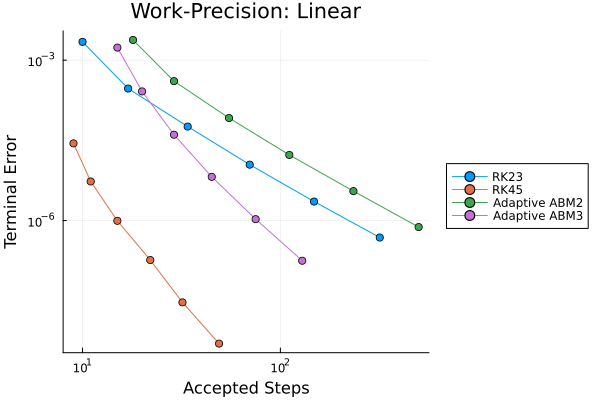

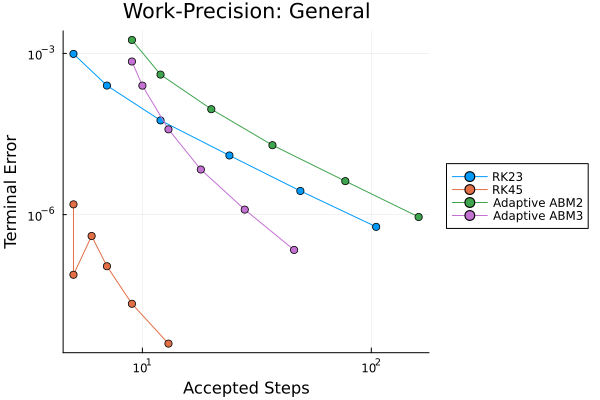

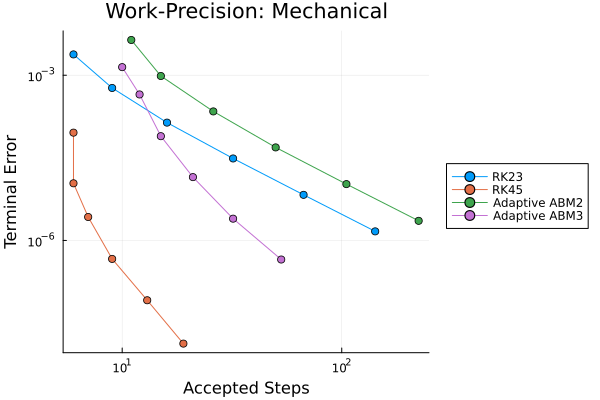

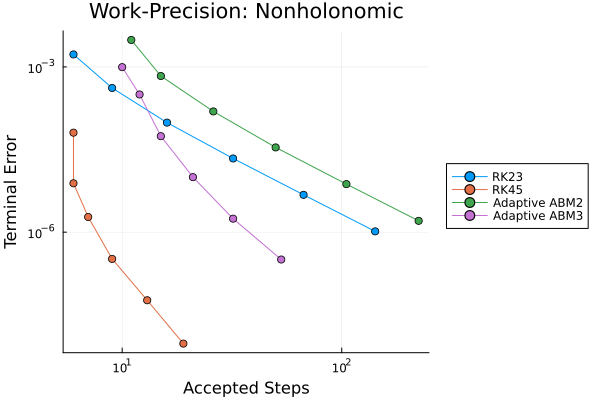

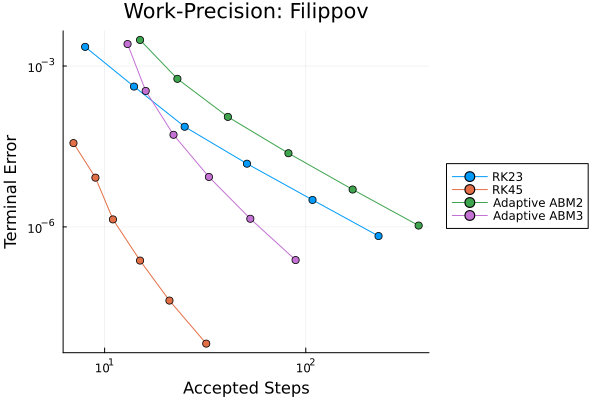

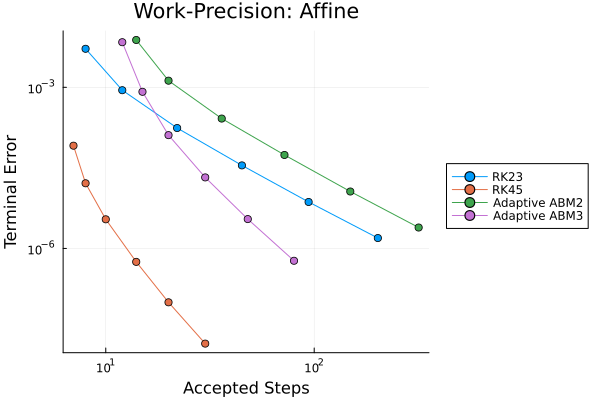

In [35]:
for system_name in keys(work_results)

    plot_work_precision(
        system_name,
        work_results[system_name]
    )

end

# Adaptive Solver Verification Summary

A successful adaptive solver implementation should satisfy three criteria:

## 1. Correct Tolerance Scaling

The measured slope $\alpha$ should be close to $\frac{p}{p+1}$.

## 2. Monotonic Error Reduction

Decreasing tolerance should generally decrease numerical error.

## 3. Competitive Work-Precision Performance

For a given accuracy requirement, efficient solvers should require fewer accepted steps. 

Together these tests verify:

- mathematical correctness,
- adaptive controller behavior,
- practical computational efficiency.
